# 11 · PCA and UMAP on Particles
Encodes particles with the frozen DINOv2 backbone, then runs:
- **Per-patch PCA** — projects each ViT patch token and saves a colour-coded overlay per particle.
- **UMAP** — projects CLS-level latents into 2D and plots per-experiment clusters.

In [1]:
# ── Configuration ─────────────────────────────────────────────────────────────
DEVICE         = 'cuda:0'
BASE_PATH      = './metadata/DINOv2_checkpoint/'
PARTICLES_DIR  = './metadata/particles/'

BATCH_SIZE     = 1024   # particles per forward pass
IM_SIZE        = 224    # particle image side length (px)
N_LAYERS       = 24     # total number of ViT layers
N_LAST_BLOCKS  = 1      # must match the value used during linear eval
PCA_COMPONENTS = 3
SAMPLE_NUM     = 1000   # particles sampled per EMPIAR experiment
N_PATCHES      = 196    # ViT patch tokens per image (14 × 14 for ViT-L/16 at 224 px)
SEED           = 44

# Particle sets to process
PARTICLE_SETS  = ('training', 'validation', '10892')

# Dataset normalisation constants (computed over the training set)
NORMALIZE_MEAN = 0.5475857690770103
NORMALIZE_STD  = 0.12047245612891117

# UMAP hyperparameters
UMAP_N_NEIGHBORS = 5
UMAP_MIN_DIST    = 0.2
UMAP_METRIC      = 'cosine'

In [2]:
import os
import json
import h5py
import numpy as np
import pandas as pd
from functools import partial

import umap.umap_ as umap
import matplotlib.pyplot as plt

import torch
import torch.distributed as dist
import torch.nn.functional as F
from PIL import Image
from sklearn.decomposition import PCA

from dinov3.eval.linear import create_linear_input
from dinov3.eval.setup import ModelConfig, load_model_and_context
from dinov3.eval.utils import ModelWithIntermediateLayers

## 1 · Initialise distributed context and load backbone

In [3]:
if not dist.is_initialized():
    dist.init_process_group(
        backend='nccl',
        rank=0,
        world_size=1,
        init_method='tcp://127.0.0.1:29600',
    )

torch.cuda.set_device(int(DEVICE.split(':')[-1]))

model_cfg = ModelConfig(
    config_file=f'{BASE_PATH}config.yaml',
    pretrained_weights=f'{BASE_PATH}teacher_checkpoint.pth',
    dino_hub=None,
)
backbone, ctx = load_model_and_context(model_cfg, output_dir=BASE_PATH)
backbone.to(DEVICE).eval()

autocast_ctx  = partial(torch.autocast, device_type='cuda', enabled=True, dtype=ctx['autocast_dtype'])
feature_model = ModelWithIntermediateLayers(backbone, N_LAST_BLOCKS, autocast_ctx)

print('Backbone ready on', DEVICE)

Backbone ready on cuda:0


## 2 · Helper functions

In [4]:
def load_h5_particles(h5_path):
    """
    Load particle images and annotations from an H5 file.

    Parameters
    ----------
    h5_path : str

    Returns
    -------
    particles      : np.ndarray, shape (N, H, W)  — uint8 particle images
    annotations_df : pd.DataFrame
    """
    with h5py.File(h5_path, 'r') as f:
        particles        = f['images'][:]
        annotations_json = f['annotations'][()].decode()
    annotations_df = pd.DataFrame.from_dict(json.loads(annotations_json))
    return particles, annotations_df


def preprocess_particles(particles, mean, std):
    """
    Normalise particle images to [0,1], apply dataset standardisation,
    and return a float32 tensor of shape (N, 1, H, W).
    """
    p = particles / 255.0
    p = (p - mean) / std
    return torch.from_numpy(p).unsqueeze(1).float()


def extract_features_per_patch(patches, backbone, n_layers, device, batch_size, autocast_dtype):
    """
    Extract per-patch token features from the last ViT layer.

    Returns
    -------
    np.ndarray, shape (N, patch_h, patch_w, D)
    """
    N, latents = patches.shape[0], []
    with torch.inference_mode():
        with torch.autocast(device_type='cuda', dtype=autocast_dtype):
            for start in range(0, N, batch_size):
                batch = patches[start : start + batch_size].to(device)
                feats = (
                    backbone.get_intermediate_layers(
                        batch, n=range(n_layers), reshape=True, norm=True
                    )[-1]
                    .cpu().float().permute(0, 2, 3, 1).numpy()
                )
                latents.append(feats)
                print(f'  {start + len(feats)}/{N}', end='\r')
    print()
    return np.concatenate(latents)  # (N, patch_h, patch_w, D)


def extract_features(patches, feature_model, n_last_blocks, device, batch_size, autocast_dtype, label=''):
    """
    Extract CLS-level features via the linear-probing feature model.

    Returns
    -------
    np.ndarray, shape (N, D)
    """
    N, latents = patches.shape[0], []
    with torch.inference_mode():
        with torch.autocast(device_type='cuda', dtype=autocast_dtype):
            for start in range(0, N, batch_size):
                batch = patches[start : start + batch_size].to(device)
                feats = create_linear_input(
                    feature_model(batch.float()), n_last_blocks, True
                ).cpu().float().numpy()
                latents.append(feats)
                print(f'  {label}  {start + len(feats)}/{N}', end='\r')
    print()
    return np.concatenate(latents)  # (N, D)


def run_pca(latents, n_components):
    """
    Fit PCA on *latents* and return the projected coordinates.

    Returns
    -------
    np.ndarray, shape (N, n_components)
    """
    pca = PCA(n_components=n_components, whiten=True).fit(latents)
    return pca.transform(latents)


def get_empiar_ids(annotations):
    """
    Extract clean EMPIAR IDs from an annotations DataFrame.

    Returns
    -------
    list[str]
    """
    raw = np.unique(annotations['EMPIAR_ID'].astype(str))
    return [i.split('.')[0].split('_')[0] for i in raw]


def run_patch_pca_per_experiment(latents, empiar_ids, sample_num, n_patches, pca_components):
    """
    Fit a per-experiment PCA on patch-level latents.

    Parameters
    ----------
    latents       : np.ndarray, shape (N_total, patch_h, patch_w, D)
    empiar_ids    : list[str]
    sample_num    : int  — particles per experiment
    n_patches     : int  — total patches per image (e.g. 196 = 14×14)
    pca_components: int

    Returns
    -------
    list[np.ndarray]  — one (sample_num, n_patches, pca_components) array per experiment
    """
    results = []
    for i in range(len(empiar_ids)):
        exp = latents[i*sample_num:(i+1)*sample_num].reshape(sample_num * n_patches, -1)
        projected = run_pca(exp, pca_components).reshape(sample_num, n_patches, -1)
        results.append(projected)
    return results


def save_particle_and_pca_overlay(particles, projected, exp_idx, ridx,
                                   eid, sample_num, n_patches, pca_components,
                                   im_size, out_dir):
    """
    Save the raw particle image and its PCA patch-token overlay for one random particle.

    Parameters
    ----------
    particles     : np.ndarray, shape (N_total, H, W)  — uint8
    projected     : np.ndarray, shape (sample_num, n_patches, pca_components)
    exp_idx       : int  — experiment index within the particle set
    ridx          : int  — index of the particle to visualise within the experiment
    eid           : str  — EMPIAR ID string used for file naming
    """
    # Save raw particle
    Image.fromarray(particles[exp_idx * sample_num + ridx]).convert('L').save(
        os.path.join(out_dir, f'{eid}_{ridx}_particle.png')
    )

    # Upsample 14×14 PCA grid to im_size
    patch_side = int(n_patches ** 0.5)
    proj_grid  = (
        torch.from_numpy(projected[ridx].reshape(patch_side, patch_side, pca_components))
        .permute(2, 0, 1).unsqueeze(0)
    )
    proj_up = F.interpolate(proj_grid, size=(im_size, im_size), mode='nearest')[0]\
               .permute(1, 2, 0).numpy()

    p_min = proj_up.min(axis=(0, 1), keepdims=True)
    p_max = proj_up.max(axis=(0, 1), keepdims=True)
    u8    = ((proj_up - p_min) / (p_max - p_min + 1e-8) * 255).astype(np.uint8)

    Image.fromarray(u8, mode='RGB').save(
        os.path.join(out_dir, f'{eid}_{ridx}_particle_PCA_{pca_components}.png')
    )


def fit_umap(X, n_neighbors, min_dist, metric, seed):
    """
    Fit a 2-D UMAP embedding on *X*.

    Returns
    -------
    np.ndarray, shape (N, 2)
    """
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=2,
        metric=metric,
        random_state=seed,
    )
    return reducer.fit_transform(X)


def plot_umap(X_umap, labels, empiar_ids, title, out_path, dpi=150):
    """
    Scatter plot of a 2-D UMAP embedding coloured by experiment, with
    EMPIAR ID labels at each cluster centroid.

    Parameters
    ----------
    X_umap     : np.ndarray, shape (N, 2)
    labels     : np.ndarray, shape (N,)  — integer experiment indices
    empiar_ids : list[str]
    title      : str
    out_path   : str
    """
    centroids = np.array([X_umap[labels == k].mean(axis=0) for k in range(len(empiar_ids))])
    cmap      = plt.colormaps['jet'].resampled(len(empiar_ids))

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(X_umap[:, 0], X_umap[:, 1], c=labels, s=5, cmap=cmap, alpha=0.7)

    for k, eid in enumerate(empiar_ids):
        cx, cy = centroids[k]
        ax.text(
            cx, cy, str(eid),
            fontsize=11, weight='bold', ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='black', alpha=0.8),
        )

    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi)
    plt.show()
    print(f'Saved → {out_path}')

## 3 · Per-patch PCA
For each experiment, samples one random particle, runs PCA on its `N_PATCHES` patch tokens, and saves a colour-coded PCA overlay upsampled to `IM_SIZE × IM_SIZE`.

In [5]:
np.random.seed(SEED)

for particle_set in PARTICLE_SETS:
    h5_path = os.path.join(PARTICLES_DIR, f'{particle_set}_particles_sample.h5')
    particles, annotations = load_h5_particles(h5_path)
    empiar_ids = get_empiar_ids(annotations)

    p       = preprocess_particles(particles, NORMALIZE_MEAN, NORMALIZE_STD)
    latents = extract_features_per_patch(
        p, backbone, N_LAYERS, DEVICE, BATCH_SIZE // 4, ctx['autocast_dtype']
    )

    all_projected = run_patch_pca_per_experiment(
        latents, empiar_ids, SAMPLE_NUM, N_PATCHES, PCA_COMPONENTS
    )

    for i, (eid, projected) in enumerate(zip(empiar_ids, all_projected)):
        ridx = np.random.randint(0, SAMPLE_NUM)
        save_particle_and_pca_overlay(
            particles, projected, i, ridx,
            eid, SAMPLE_NUM, N_PATCHES, PCA_COMPONENTS, IM_SIZE, PARTICLES_DIR
        )
        print(f'  [{i+1}/{len(empiar_ids)}] {particle_set} / {eid} — saved particle {ridx}')

  30000/30000
  [1/30] training / 10025 — saved particle 683
  [2/30] training / 10049 — saved particle 586
  [3/30] training / 10075 — saved particle 773
  [4/30] training / 10076 — saved particle 932
  [5/30] training / 10099 — saved particle 861
  [6/30] training / 10122 — saved particle 282
  [7/30] training / 10217 — saved particle 354
  [8/30] training / 10264 — saved particle 296
  [9/30] training / 10308 — saved particle 444
  [10/30] training / 10328 — saved particle 957
  [11/30] training / 10379 — saved particle 996
  [12/30] training / 10389 — saved particle 564
  [13/30] training / 10398 — saved particle 825
  [14/30] training / 10483 — saved particle 360
  [15/30] training / 10669 — saved particle 929
  [16/30] training / 10786 — saved particle 32
  [17/30] training / 10810 — saved particle 692
  [18/30] training / 10874 — saved particle 150
  [19/30] training / 11267 — saved particle 930
  [20/30] training / 11268 — saved particle 487
  [21/30] training / 11556 — saved p

## 4 · UMAP
Projects CLS-level latents into 2D and plots a scatter coloured by experiment, with EMPIAR ID labels at each cluster centroid.

  Particles  30000/30000


/home/azamanos/miniconda3/envs/cryoPANDA/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


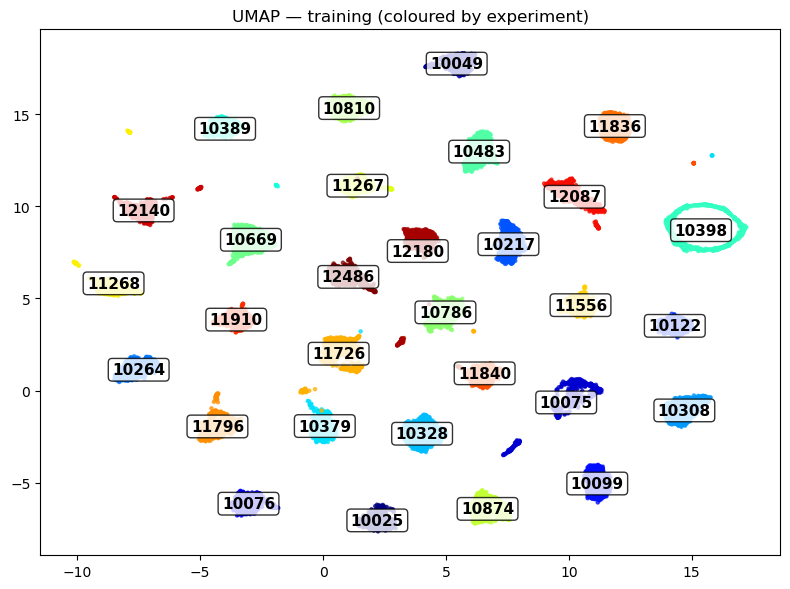

Saved → ./metadata/particles/training_particles_umap.png
  Particles  30000/30000


/home/azamanos/miniconda3/envs/cryoPANDA/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


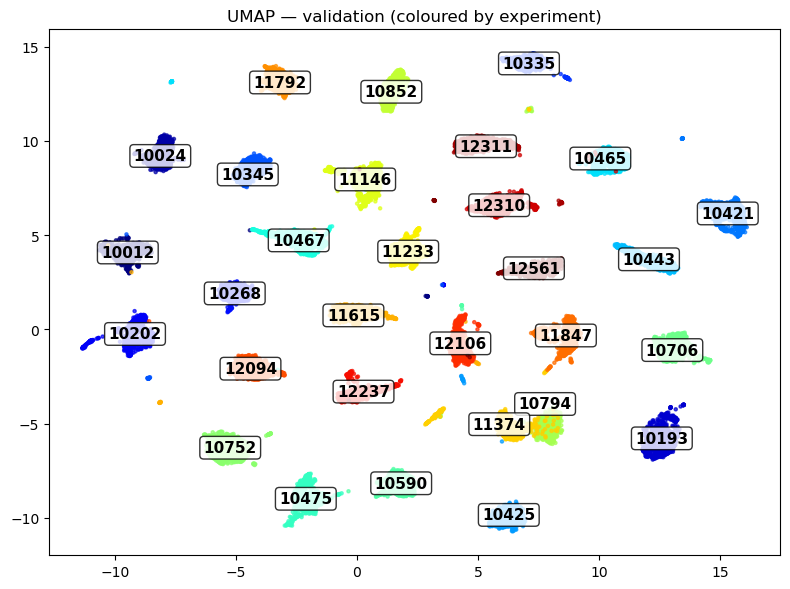

Saved → ./metadata/particles/validation_particles_umap.png
  Particles  4000/4000


/home/azamanos/miniconda3/envs/cryoPANDA/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


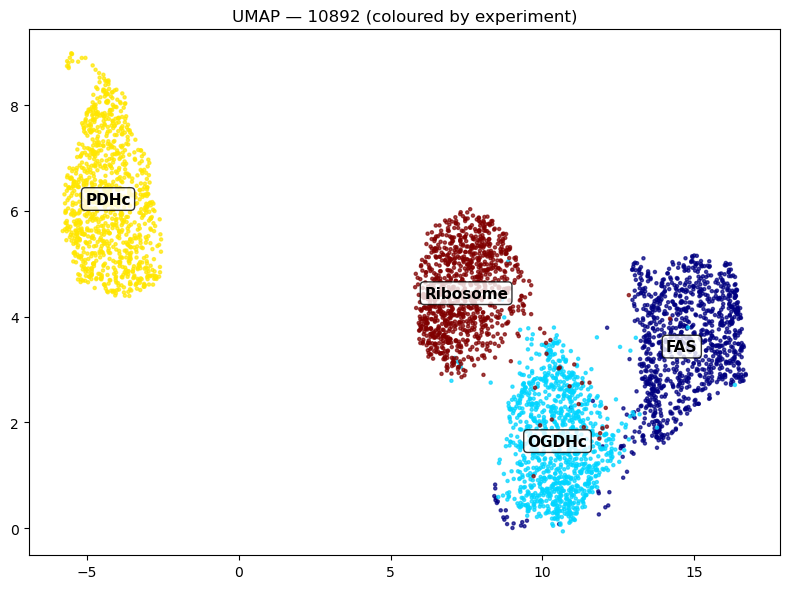

Saved → ./metadata/particles/10892_particles_umap.png


In [6]:
for particle_set in PARTICLE_SETS:
    h5_path = os.path.join(PARTICLES_DIR, f'{particle_set}_particles_sample.h5')
    particles, annotations = load_h5_particles(h5_path)
    empiar_ids = get_empiar_ids(annotations)

    p       = preprocess_particles(particles, NORMALIZE_MEAN, NORMALIZE_STD)
    latents = extract_features(
        p, feature_model, N_LAST_BLOCKS, DEVICE, BATCH_SIZE, ctx['autocast_dtype'], 'Particles'
    )

    labels = np.repeat(np.arange(len(empiar_ids)), SAMPLE_NUM)
    X_umap = fit_umap(latents, UMAP_N_NEIGHBORS, UMAP_MIN_DIST, UMAP_METRIC, 37)

    plot_umap(
        X_umap, labels, empiar_ids,
        title=f'UMAP — {particle_set} (coloured by experiment)',
       out_path=os.path.join(PARTICLES_DIR, f'{particle_set}_particles_umap.png'),
    )